In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [2]:
# load the dataset
curr_path = os.getcwd()
train_path = os.path.join(os.path.split(curr_path)[0],"data", "train_listings.csv") 
test_path = os.path.join(os.path.split(curr_path)[0],"data", "test_listings.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Get to know the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5056 non-null   int64  
 1   listing_url                                   5056 non-null   object 
 2   scrape_id                                     5056 non-null   int64  
 3   last_scraped                                  5056 non-null   object 
 4   source                                        5056 non-null   object 
 5   name                                          5056 non-null   object 
 6   description                                   4890 non-null   object 
 7   neighborhood_overview                         2506 non-null   object 
 8   picture_url                                   5056 non-null   object 
 9   host_id                                       5056 non-null   i

We want to use only the descriptions of the houses in order to asses their price. 
By the description we mean the infromation from:
- "name"
- "description"
- "neighborhood_overview"
- "property_type"
- "room_type"
- "amenities"

In addition we will also add the information about the:
- "accommodates" (number of people that can stay in the house)
- "bedrooms" (number of bedrooms in the house)
- "beds" (number of beds in the house)
- "bathrooms" (number of bathrooms in the house)

First, remove all the columns that we do not need. 
Then, we will check if there are any missing values in the dataset.

In [4]:
from utils.data_processing import get_investigated_features
# preprocess the train and test datasets
train_df = get_investigated_features(train_df)
test_df = get_investigated_features(test_df)

# Prepocess the datasets

As one can see, the prices should be converted to the numeric values.

In [7]:
# remove the '$' sign and ',' from the price column
train_df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
# convert the price column to numeric
train_df["price"] = pd.to_numeric(train_df["price"], errors='coerce')

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   5056 non-null   object 
 1   description            4890 non-null   object 
 2   neighborhood_overview  2506 non-null   object 
 3   property_type          5056 non-null   object 
 4   room_type              5056 non-null   object 
 5   amenities              5056 non-null   object 
 6   price                  5056 non-null   float64
 7   accommodates           5056 non-null   int64  
 8   bedrooms               5055 non-null   float64
 9   beds                   5048 non-null   float64
 10  bathrooms              5056 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 434.6+ KB


<Axes: xlabel='price', ylabel='bedrooms'>

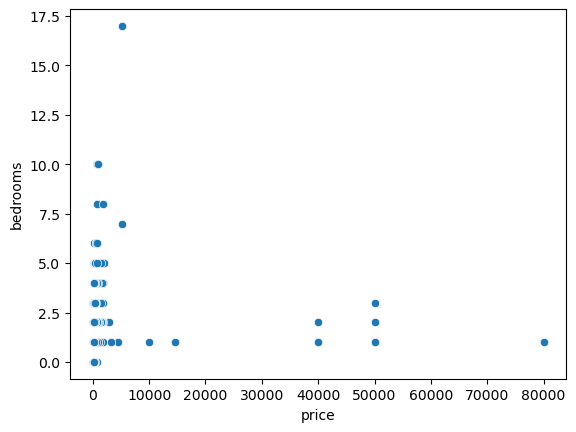